
1. **Qualitative:** captions for several held-out test images should be
   **different and relevant** - not the same word repeated.
2. **Quantitative:** BLEU-1 and BLEU-2 on the test set.

In [1]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import corpus_bleu

In [3]:
with open("../artifacts/features.pkl", "rb") as f:
    features = pickle.load(f)
with open("../artifacts/mapping.pkl", "rb") as f:
    mapping = pickle.load(f)
with open("../artifacts/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [5]:
all_captions = [c for caps in mapping.values() for c in caps]

In [6]:
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)

In [7]:
print(f"total unique words : {vocab_size-1}")
print(f"max caption length : {max_length}")

total unique words : 8780
max caption length : 37


In [2]:
model = load_model("../artifacts/model.h5", compile=False)

In [8]:
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

In [11]:
index_to_word

{1: 'a',
 2: 'startseq',
 3: 'endseq',
 4: 'in',
 5: 'the',
 6: 'on',
 7: 'is',
 8: 'and',
 9: 'dog',
 10: 'with',
 11: 'man',
 12: 'of',
 13: 'two',
 14: 'white',
 15: 'black',
 16: 'boy',
 17: 'are',
 18: 'woman',
 19: 'girl',
 20: 'to',
 21: 'wearing',
 22: 'at',
 23: 'people',
 24: 'water',
 25: 'red',
 26: 'young',
 27: 'brown',
 28: 'an',
 29: 'his',
 30: 'blue',
 31: 'dogs',
 32: 'running',
 33: 'through',
 34: 'playing',
 35: 'while',
 36: 'down',
 37: 'shirt',
 38: 'standing',
 39: 'ball',
 40: 'little',
 41: 'grass',
 42: 'child',
 43: 'person',
 44: 'snow',
 45: 'jumping',
 46: 'over',
 47: 'front',
 48: 'three',
 49: 'sitting',
 50: 'holding',
 51: 'field',
 52: 'small',
 53: 'up',
 54: 'by',
 55: 'large',
 56: 'green',
 57: 'group',
 58: 'one',
 59: 'yellow',
 60: 'her',
 61: 'walking',
 62: 'children',
 63: 'men',
 64: 'into',
 65: 'air',
 66: 'beach',
 67: 'near',
 68: 'mouth',
 69: 'jumps',
 70: 'another',
 71: 'for',
 72: 'street',
 73: 'runs',
 74: 'its',
 75: 'from',

In [10]:
len(index_to_word)

8780

In [14]:
def get_word(index):
    return index_to_word.get(index)

In [15]:
def predict_caption(model, image_feature, tokenizer, max_length):
    text = "startseq"
    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([text])[0]
        seq = pad_sequences([seq], maxlen=max_length)
        y_pred = model.predict([image_feature, seq], verbose=0)
        index = int(np.argmax(y_pred))
        word = get_word(index)
        if word is None:
            break
        text += " " + word
        if word == "endseq":
            break
    return text

In [16]:
def clean_caption(text):
    return text.replace("startseq", "").replace("endseq", "").strip()

In [18]:
# We generate greedily: start from startseq, repeatedly predict the most likely
# next word, and stop at endseq.

In [19]:
image_ids = list(mapping.keys())

In [20]:
train_ids, test_ids = train_test_split(image_ids, test_size=0.1, random_state=42)

In [21]:
print(len(train_ids), len(test_ids))

7281 810


## Qualitative check - captions should differ from image to image

In [22]:
for image_id in test_ids[:10]:
    pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print("image    :", image_id)
    print("predicted:", clean_caption(pred))
    print("reference:", clean_caption(mapping[image_id][0]))
    print("-" * 60)

image    : 3139895886_5a6d495b13
predicted: a black and white dog is running through the grass
reference: a blackandwhite dog bounds off the ground all feet in the air of a yellow field
------------------------------------------------------------
image    : 3133825703_359a0c414d
predicted: a man in a red jacket is standing in the snow
reference: a child staring at santa
------------------------------------------------------------
image    : 244910177_7c4ec3f65b
predicted: a group of people in a white shirt and a woman in a white shirt and a woman in a white shirt and a woman in a white shirt
reference: three woman walk down a city street and one has a pink purse
------------------------------------------------------------
image    : 2127207912_9298824e66
predicted: a man climbs a rock face
reference: the two people are standing on a rock holding themselves up against another rock while looking down
------------------------------------------------------------
image    : 1810651611_35aae

## Show some test images with their predicted captions

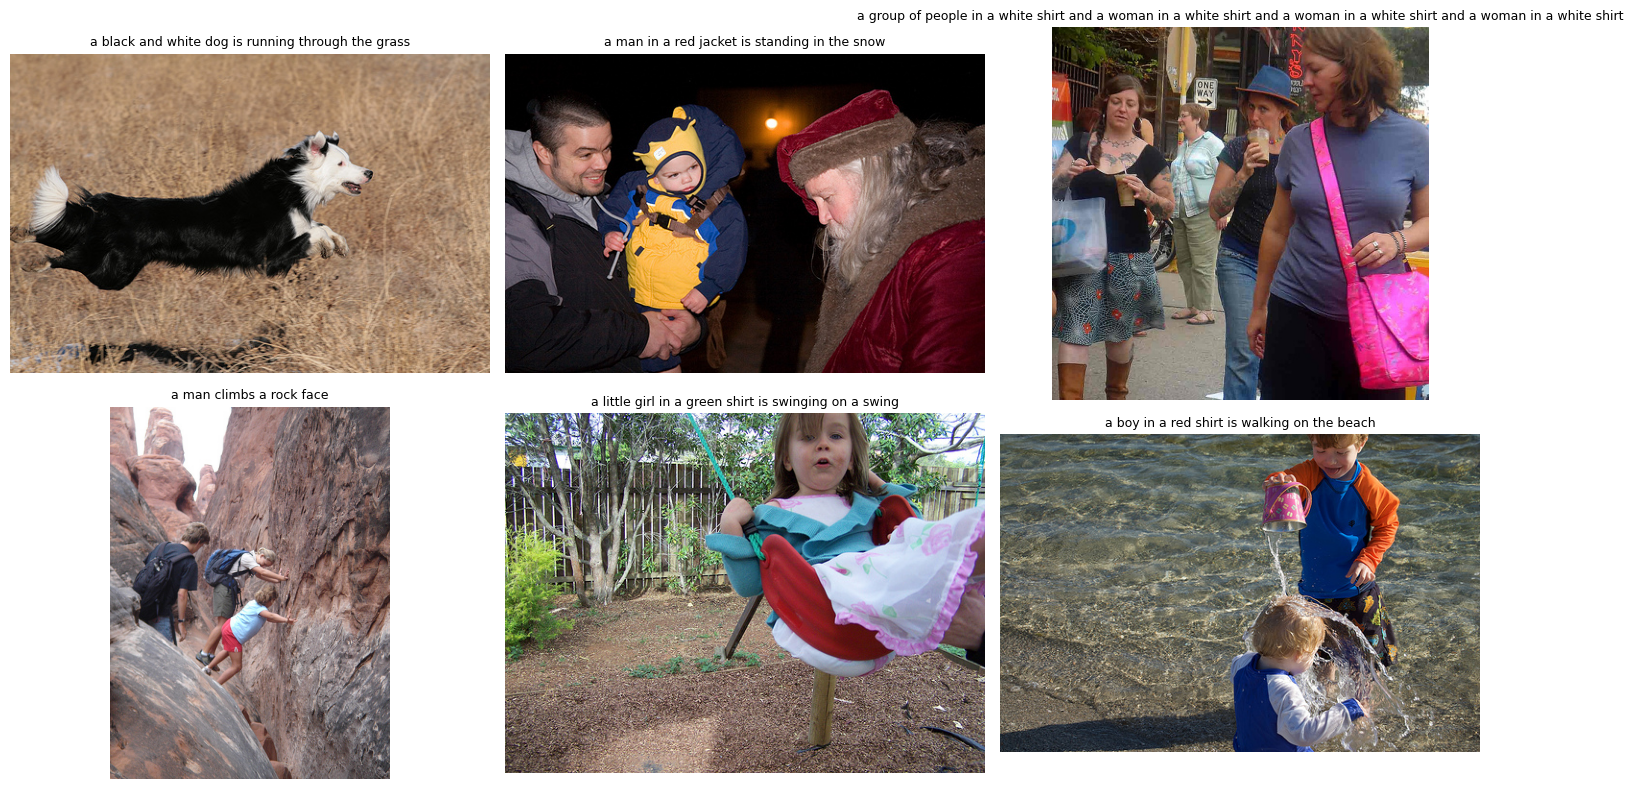

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, image_id in zip(axes.ravel(), test_ids[:6]):
    img_path = os.path.join("../artifacts/Flickr8k/Images", image_id + ".jpg")
    ax.imshow(Image.open(img_path))
    ax.axis("off")
    caption = clean_caption(predict_caption(model, features[image_id], tokenizer, max_length))
    ax.set_title(caption, fontsize=9)
plt.tight_layout()
plt.show()


BLEU score tells us how closely the model’s generated caption matches the human-written caption.

In [24]:
sample_test = test_ids[:200]

In [25]:
actual, predicted = [],[]

for image_id in sample_test:
    pred = predict_caption(model, features[image_id], tokenizer, max_length)
    references = [clean_caption(c).split() for c in mapping[image_id]]
    actual.append(references)
    predicted.append(clean_caption(pred).split())

In [26]:
print("BLEU-1: %.4f" % corpus_bleu(actual,predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %.4f" % corpus_bleu(actual,predicted, weights=(0.5, 0.5, 0, 0)))

BLEU-1: 0.5387
BLEU-2: 0.3584
